# Prediccion del Tipo de Cambio USD/GEL con RNN
### Moneda: Lari Georgiano (GEL) — Georgia

## Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
device = 'cpu'
print('Dispositivo:', device)

Dispositivo: cpu


## Carga del Dataset

In [2]:
RUTA = r'C:\Users\Usuario\Desktop\INTELIG. ARTIF. 2\P1\DATASET\DatasetLARI\USD_GEL Historical Data.csv'

df = pd.read_csv(RUTA)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Rango: {df["Date"].iloc[0].date()}  a  {df["Date"].iloc[-1].date()}')
print(f'Filas: {len(df)}')
df.head()

Rango: 2001-05-11  a  2020-10-27
Filas: 4999


,Date,Price,Open,High,Low,Vol.,Change %
0,2001-05-11,2.0550,2.0550,2.0550,2.0550,NaN,0.24%
1,2001-05-14,2.0570,2.0570,2.0570,2.0570,NaN,0.10%
2,2001-05-15,2.0595,2.0595,2.0595,2.0595,NaN,0.12%
3,2001-05-16,2.0650,2.0650,2.0650,2.0650,NaN,0.27%
4,2001-05-17,2.0700,2.0700,2.0700,2.0700,NaN,0.24%


## Preprocesamiento

In [4]:
FEATURES   = ['Price', 'Open', 'High', 'Low']
ULTIMO_MES = 22
N_STEPS    = 14

df = df[['Date'] + FEATURES].dropna().reset_index(drop=True)

scaler     = MinMaxScaler()
datos_norm = scaler.fit_transform(df[FEATURES]).astype(np.float32)

datos_train_raw = datos_norm[:-ULTIMO_MES]
datos_test_raw  = datos_norm[-ULTIMO_MES:]
fechas_test     = df['Date'].iloc[-ULTIMO_MES:].values
precios_reales  = df['Price'].iloc[-ULTIMO_MES:].values

print(f'Train: {len(datos_train_raw)} dias')
print(f'Test : {len(datos_test_raw)} dias')

Train: 4977 dias
Test : 22 dias


## Ventanas Deslizantes

In [5]:
def build_windows(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i : i + n_steps])
        y.append(data[i + n_steps, [0]])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = build_windows(datos_train_raw, N_STEPS)

split_train      = int(len(X_all) * 0.8)
X_train, y_train = X_all[:split_train], y_all[:split_train]
X_valid, y_valid = X_all[split_train:], y_all[split_train:]

X_test_raw     = np.concatenate([datos_train_raw[-N_STEPS:], datos_test_raw], axis=0)
X_test, y_test = build_windows(X_test_raw, N_STEPS)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_valid: {X_valid.shape} | y_valid: {y_valid.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')

X_train: (3970, 14, 4) | y_train: (3970, 1)
X_valid: (993, 14, 4) | y_valid: (993, 1)
X_test : (22, 14, 4)  | y_test : (22, 1)


## Dataset y DataLoader

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X     = X
        self.y     = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval' : TimeSeriesDataset(X_valid, y_valid),
    'test' : TimeSeriesDataset(X_test,  train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64)
}

## Modelo RNN

A diferencia del MLP que aplana toda la ventana en un vector, la RNN procesa la secuencia dia a dia manteniendo un estado oculto que acumula informacion del pasado. Cada nuevo dia actualiza ese estado, lo que permite capturar dependencias temporales que el MLP ignora.

In [7]:
class RNN(nn.Module):
    def __init__(self, n_features=4, hidden_size=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = n_layers,
            batch_first = True,
            dropout     = dropout if n_layers > 1 else 0.0,
            nonlinearity= 'tanh'
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out    = self.dropout(out[:, -1, :])
        return self.fc(out)

rnn = RNN(n_features=len(FEATURES)).to(device)
print(rnn)
total_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f'\nParametros entrenables: {total_params:,}')

RNN(
  (rnn): RNN(4, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parametros entrenables: 12,865


## Entrenamiento con Early Stopping

In [8]:
EPOCHS   = 200
LR       = 5e-4
PATIENCE = 15

optimizer = torch.optim.Adam(rnn.parameters(), lr=LR)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7
)

best_val_loss     = float('inf')
epochs_sin_mejora = 0
best_weights      = None
history           = {'train': [], 'val': []}

for epoch in tqdm(range(1, EPOCHS + 1), desc='Entrenando'):

    rnn.train()
    train_loss = 0.0
    for X_batch, y_batch in dataloader['train']:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(rnn(X_batch), y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(rnn.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(dataset['train'])

    rnn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in dataloader['eval']:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_loss += criterion(rnn(X_batch), y_batch).item() * len(X_batch)
    val_loss /= len(dataset['eval'])

    history['train'].append(train_loss)
    history['val'].append(val_loss)
    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        lr_actual = optimizer.param_groups[0]['lr']
        print(f'Epoca {epoch:>3} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr_actual:.6f}')

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_weights      = {k: v.clone() for k, v in rnn.state_dict().items()}
        epochs_sin_mejora = 0
    else:
        epochs_sin_mejora += 1
        if epochs_sin_mejora >= PATIENCE:
            print(f'Early stopping en epoca {epoch} | Mejor Val Loss: {best_val_loss:.6f}')
            break

rnn.load_state_dict(best_weights)
print(f'Entrenamiento finalizado | Mejor Val Loss: {best_val_loss:.6f}')

Entrenando:   0%|          | 1/200 [00:00<02:21,  1.41it/s]

Epoca   1 | Train: 0.004761 | Val: 0.001978 | LR: 0.000500


Entrenando:   5%|▌         | 10/200 [00:05<01:54,  1.66it/s]

Epoca  10 | Train: 0.000418 | Val: 0.001145 | LR: 0.000500


Entrenando:  10%|█         | 20/200 [00:12<01:58,  1.52it/s]

Epoca  20 | Train: 0.000298 | Val: 0.000661 | LR: 0.000500


Entrenando:  14%|█▍        | 29/200 [00:19<01:52,  1.52it/s]

Epoca  30 | Train: 0.000249 | Val: 0.001036 | LR: 0.000250
Early stopping en epoca 30 | Mejor Val Loss: 0.000407
Entrenamiento finalizado | Mejor Val Loss: 0.000407


## Curva de Entrenamiento

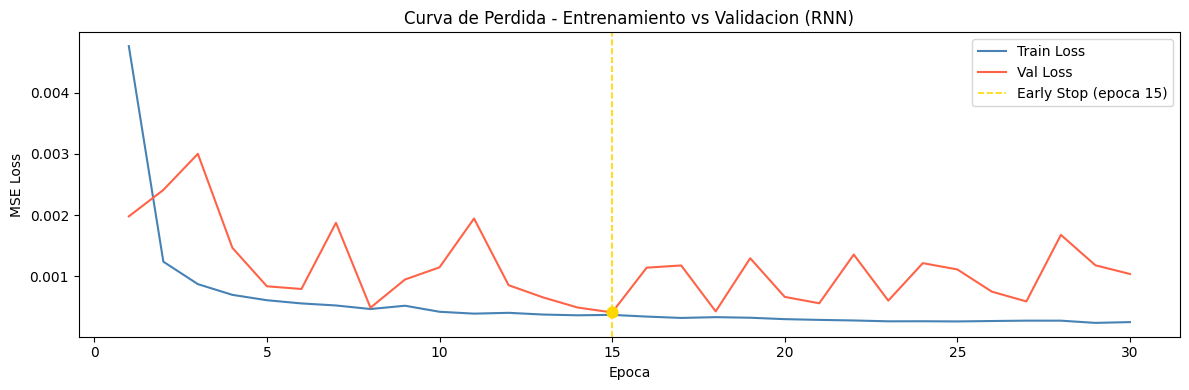

In [9]:
epochs_range = range(1, len(history['train']) + 1)
mejor_epoca  = history['val'].index(min(history['val'])) + 1
mejor_loss   = min(history['val'])

plt.figure(figsize=(12, 4))
plt.plot(epochs_range, history['train'], color='steelblue', linewidth=1.5, label='Train Loss')
plt.plot(epochs_range, history['val'],   color='tomato',    linewidth=1.5, label='Val Loss')
plt.axvline(x=mejor_epoca, color='gold', linestyle='--', linewidth=1.2, label=f'Early Stop (epoca {mejor_epoca})')
plt.scatter(mejor_epoca, mejor_loss, color='gold', zorder=5, s=60)
plt.title('Curva de Perdida - Entrenamiento vs Validacion (RNN)')
plt.xlabel('Epoca')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Grafica: Prediccion vs Real (Test Set)

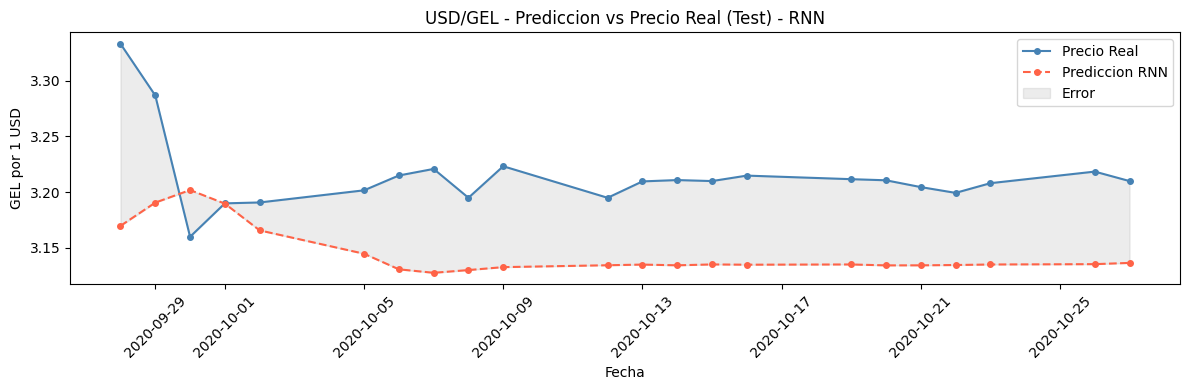

     Fecha   Real  Prediccion  Error Abs
2020-09-28 3.3332      3.1698     0.1634
2020-09-29 3.2868      3.1907     0.0961
2020-09-30 3.1600      3.2019     0.0419
2020-10-01 3.1900      3.1898     0.0002
2020-10-02 3.1908      3.1657     0.0251
2020-10-05 3.2017      3.1448     0.0569
2020-10-06 3.2150      3.1308     0.0842
2020-10-07 3.2209      3.1277     0.0932
2020-10-08 3.1950      3.1301     0.0649
2020-10-09 3.2233      3.1328     0.0905
2020-10-12 3.1950      3.1345     0.0605
2020-10-13 3.2097      3.1351     0.0746
2020-10-14 3.2109      3.1344     0.0765
2020-10-15 3.2100      3.1352     0.0748
2020-10-16 3.2149      3.1349     0.0800
2020-10-19 3.2117      3.1352     0.0765
2020-10-20 3.2107      3.1343     0.0764
2020-10-21 3.2046      3.1344     0.0702
2020-10-22 3.1994      3.1347     0.0647
2020-10-23 3.2081      3.1351     0.0730
2020-10-26 3.2185      3.1354     0.0831
2020-10-27 3.2100      3.1366     0.0734


In [11]:
plt.figure(figsize=(12, 4))
plt.plot(fechas_test, precios_reales, color='steelblue', linewidth=1.5, marker='o', markersize=4, label='Precio Real')
plt.plot(fechas_test, preds_reales,   color='tomato',    linewidth=1.5, marker='o', markersize=4, label='Prediccion RNN', linestyle='--')
plt.fill_between(fechas_test, precios_reales, preds_reales, alpha=0.15, color='gray', label='Error')
plt.title('USD/GEL - Prediccion vs Precio Real (Test) - RNN')
plt.xlabel('Fecha')
plt.ylabel('GEL por 1 USD')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

comparativa = pd.DataFrame({
    'Fecha'     : fechas_test,
    'Real'      : precios_reales.round(4),
    'Prediccion': preds_reales.round(4),
    'Error Abs' : np.abs(precios_reales - preds_reales).round(4)
})
print(comparativa.to_string(index=False))

## Prediccion de 30 Dias Futuros

In [12]:
DIAS_FUTURO = 30

ventana_actual       = datos_norm[-N_STEPS:].copy()
predicciones_futuras = []

rnn.eval()
with torch.no_grad():
    for _ in range(DIAS_FUTURO):
        x_in  = torch.from_numpy(ventana_actual[np.newaxis]).to(device)
        pred  = rnn(x_in).cpu().numpy()[0, 0]
        predicciones_futuras.append(pred)

        nuevo_paso    = ventana_actual[-1].copy()
        nuevo_paso[0] = pred
        ventana_actual = np.vstack([ventana_actual[1:], nuevo_paso])

dummy_fut       = np.zeros((DIAS_FUTURO, 4), dtype=np.float32)
dummy_fut[:, 0] = predicciones_futuras
predicciones_futuras_reales = scaler.inverse_transform(dummy_fut)[:, 0]

ultima_fecha  = df['Date'].iloc[-1]
fechas_futuro = pd.date_range(start=ultima_fecha + pd.Timedelta(days=1), periods=DIAS_FUTURO, freq='B')

df_futuro = pd.DataFrame({
    'Fecha'     : fechas_futuro,
    'Prediccion': predicciones_futuras_reales.round(4)
})
print(df_futuro.to_string(index=False))

     Fecha  Prediccion
2020-10-28      3.1376
2020-10-29      3.1338
2020-10-30      3.1295
2020-11-02      3.1275
2020-11-03      3.1263
2020-11-04      3.1262
2020-11-05      3.1263
2020-11-06      3.1266
2020-11-09      3.1269
2020-11-10      3.1270
2020-11-11      3.1271
2020-11-12      3.1271
2020-11-13      3.1271
2020-11-16      3.1270
2020-11-17      3.1270
2020-11-18      3.1270
2020-11-19      3.1270
2020-11-20      3.1270
2020-11-23      3.1270
2020-11-24      3.1270
2020-11-25      3.1270
2020-11-26      3.1270
2020-11-27      3.1270
2020-11-30      3.1270
2020-12-01      3.1270
2020-12-02      3.1270
2020-12-03      3.1270
2020-12-04      3.1270
2020-12-07      3.1270
2020-12-08      3.1270


## Grafica: Predicciones Futuras

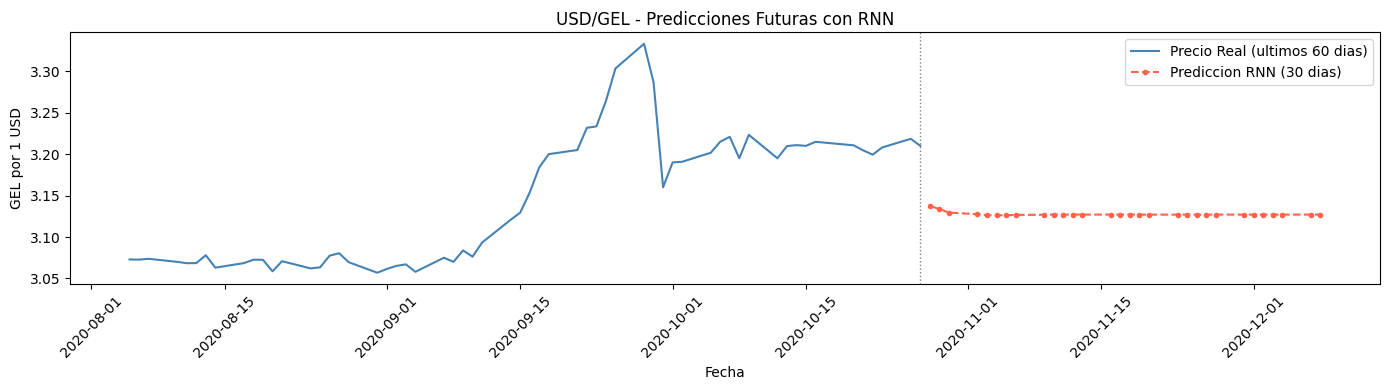

In [13]:
ultimos_reales = df['Price'].iloc[-60:].values
fechas_reales  = df['Date'].iloc[-60:].values

plt.figure(figsize=(14, 4))
plt.plot(fechas_reales, ultimos_reales,              color='steelblue', linewidth=1.5, label='Precio Real (ultimos 60 dias)')
plt.plot(fechas_futuro, predicciones_futuras_reales, color='tomato',    linewidth=1.5, linestyle='--', marker='o', markersize=3, label=f'Prediccion RNN ({DIAS_FUTURO} dias)')
plt.axvline(x=ultima_fecha, color='gray', linestyle=':', linewidth=1)
plt.title('USD/GEL - Predicciones Futuras con RNN')
plt.xlabel('Fecha')
plt.ylabel('GEL por 1 USD')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()